# Notebook Overview — Extract Gradient Features

## Purpose

This notebook extracts the **gradient-based feature set** from preprocessed images using the train or test metadata CSV files generated earlier in the pipeline.

---

## Inputs

The notebook expects the following:

* Metadata CSV files from the GitHub repository:

  * `metadata/splits/train_metadata.csv`
  * `metadata/splits/test_metadata.csv`

* Preprocessed image archive from Google Drive:

  * `/content/drive/MyDrive/DIP_Project/releases/preprocessed/All_Sources_preprocessed.zip`

---

## Assumptions

* Each metadata CSV contains the columns:

  * `filename`
  * `class_label`
  * `source_dataset`
  * `subset`

* The metadata was created previously by the combine-and-split notebook
* The preprocessed images are stored in a single ZIP archive
* All preprocessed images are:

  * grayscale
  * resized to **256 × 256**
  * saved as `.png` files

* This notebook does **not** download, split, or preprocess images
* Feature extraction is performed on a **single subset per run** to preserve split integrity
* Image selection is metadata-driven and does not depend on directory traversal

---

## What This Notebook Does

### Cell 1 — Environment Setup

* Mount Google Drive to access the preprocessed image archive
* Clone the GitHub repository into the local runtime
* Import `project_config.py`
* Select the subset to process (`train` or `test`)
* Verify required metadata and ZIP archive inputs
* Create required output directories

---

### Cell 2 — Extract Preprocessed Images

* Extract the preprocessed image archive if needed
* Verify that extracted PNG images are available locally

---

### Cell 3 — Define Gradient Feature Functions

* Define Sobel gradient computation
* Define gradient magnitude and orientation logic
* Define gradient-based feature extraction

---

### Cell 4 — Preview and Validate Sample Image

* Load a sample image using metadata
* Verify image format and dimensions
* Compute and display gradient-based features
* Visualize gradient magnitude, orientation, and edge mask

---

### Cell 5 — Extract Gradient Features

For each image in the selected subset metadata file:

1. Load the preprocessed image
2. Compute the gradient-based feature set
3. Store features together with metadata fields

The gradient feature group includes:

* Mean Gradient
* Std Gradient
* Max Gradient
* Gradient Entropy
* Edge Density
* Orientation Mean
* Orientation Std
* Orientation Entropy

---

### Cell 6 — Save Output

* Save extracted features to a subset-specific CSV file
* Verify file creation and row count

---

### Cell 7 — Final Summary

* Display processing summary
* Confirm output path
* Provide guidance for generating the remaining subset

---

## Outputs

The following files are written under `metadata/features/`:

* `metadata/features/train_gradient_features.csv`
* `metadata/features/test_gradient_features.csv`

---

## Expected Sizes

* `train_gradient_features.csv` → **14,400 rows**
* `test_gradient_features.csv` → **3,600 rows**

Each row corresponds to one image and includes metadata plus extracted gradient features.

---

## Notes

* The project contains **6 total sources** and **18,000 images**
* Each source contributes **3,000 images**
* The split is performed earlier with exact per-source counts:

  * **train = 2400 per source**
  * **test = 600 per source**

* This notebook extracts only the **gradient-based** feature group
* Spatial and frequency-domain features are extracted in separate notebooks

* This notebook must be run **twice**:
  1. Once with `SUBSET_NAME = TRAIN_SUBSET`
  2. Once with `SUBSET_NAME = TEST_SUBSET`

In [6]:
# ============================================
# Cell 1: Startup (Environment + Verification)
# ============================================

import os
import sys
import zipfile
from pathlib import Path

# -------------------------------------------------
# Notebook display control
# -------------------------------------------------
VERBOSE = True   # Set to False to reduce detailed output

# -------------------------------------------------
# Mount Google Drive to access release ZIP archive
# -------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

# -------------------------------------------------
# Clone GitHub repository into Colab runtime
# -------------------------------------------------
REPO_URL = "https://github.com/pgailinas/dip-ai-image-detection.git"
REPO_DIR = Path("/content/dip-ai-image-detection")

if not REPO_DIR.exists():
    print("Cloning repository...")
    os.system(f"git clone {REPO_URL} {REPO_DIR}")

# -------------------------------------------------
# Make src/ importable
# -------------------------------------------------
SRC_DIR = REPO_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# -------------------------------------------------
# Import shared project configuration
# -------------------------------------------------
from project_config import (
    TRAIN_SUBSET,
    TEST_SUBSET,
    TRAIN_METADATA_PATH,
    TEST_METADATA_PATH,
    TRAIN_GRADIENT_FEATURES_PATH,
    TEST_GRADIENT_FEATURES_PATH,
    PREPROCESSED_ZIP_PATHS,
    PROCESSED_DATA_DIR,
    FEATURES_METADATA_DIR,
)

# -------------------------------------------------
# Convert configured paths to Path objects
# -------------------------------------------------
TRAIN_METADATA_FILE = Path(TRAIN_METADATA_PATH)
TEST_METADATA_FILE = Path(TEST_METADATA_PATH)

TRAIN_OUTPUT_FILE = Path(TRAIN_GRADIENT_FEATURES_PATH)
TEST_OUTPUT_FILE = Path(TEST_GRADIENT_FEATURES_PATH)

PREPROCESSED_ZIP = Path(PREPROCESSED_ZIP_PATHS["all_sources"])

EXTRACTED_IMAGE_DIR = Path(PROCESSED_DATA_DIR) / "images"
FEATURES_DIR = Path(FEATURES_METADATA_DIR)

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
EXTRACTED_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Select subset to process
# -------------------------------------------------
SUBSET_NAME = TRAIN_SUBSET   # change to TEST_SUBSET for test run

if SUBSET_NAME == TRAIN_SUBSET:
    METADATA_FILE = TRAIN_METADATA_FILE
    OUTPUT_FILE = TRAIN_OUTPUT_FILE
elif SUBSET_NAME == TEST_SUBSET:
    METADATA_FILE = TEST_METADATA_FILE
    OUTPUT_FILE = TEST_OUTPUT_FILE
else:
    raise ValueError(f"Invalid SUBSET_NAME: {SUBSET_NAME}")

# -------------------------------------------------
# Verify required inputs
# -------------------------------------------------
print("Verifying required inputs...\n")

required_files = [
    METADATA_FILE,
    PREPROCESSED_ZIP,
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Missing required file: {file_path}")

print("Required input files are present.")

if VERBOSE:
    print(f"Subset selected:  {SUBSET_NAME}")
    print(f"Metadata file:    {METADATA_FILE}")
    print(f"Preprocessed ZIP: {PREPROCESSED_ZIP}")
    print(f"Extracted images: {EXTRACTED_IMAGE_DIR}")
    print(f"Output file:      {OUTPUT_FILE}")

# -------------------------------------------------
# Extract ZIP only if needed
# -------------------------------------------------
existing_png_count = len(list(EXTRACTED_IMAGE_DIR.glob("*.png")))

if existing_png_count > 0:
    print(f"\nExtracted image directory already contains {existing_png_count} PNG files.")
    print("Skipping extraction.")
else:
    print("\nExtracting All_Sources_preprocessed.zip to local runtime...")
    with zipfile.ZipFile(PREPROCESSED_ZIP, "r") as zip_ref:
        zip_ref.extractall(EXTRACTED_IMAGE_DIR)
    print("Extraction complete.")

# -------------------------------------------------
# Verify extracted images
# -------------------------------------------------
image_files = list(EXTRACTED_IMAGE_DIR.glob("*.png"))

if len(image_files) == 0:
    raise FileNotFoundError(
        f"No PNG files found in extracted image directory: {EXTRACTED_IMAGE_DIR}"
    )

print(f"Found {len(image_files)} extracted PNG files.")
print("\nStartup complete.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Verifying required inputs...

Required input files are present.
Subset selected:  train
Metadata file:    /content/dip-ai-image-detection/metadata/splits/train_metadata.csv
Preprocessed ZIP: /content/drive/MyDrive/DIP_Project/releases/preprocessed/All_Sources_preprocessed.zip
Extracted images: /content/dip-ai-image-detection/data/preprocessed/images
Output file:      /content/dip-ai-image-detection/metadata/features/train_gradient_features.csv

Extracted image directory already contains 18000 PNG files.
Skipping extraction.
Found 18000 extracted PNG files.

Startup complete.


In [13]:
# ============================================
# Cell 2: Load Metadata
# ============================================

import pandas as pd

# -------------------------------------------------
# Load selected subset metadata
# -------------------------------------------------
df = pd.read_csv(METADATA_FILE)

print(f"Loaded metadata for subset: {SUBSET_NAME}")
print(f"Metadata shape: {df.shape}")

# -------------------------------------------------
# Basic column verification
# -------------------------------------------------
required_columns = ["filename", "class_label", "source_dataset", "subset"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Metadata file is missing required columns: {missing_columns}")

print("Required metadata columns verified.")

# -------------------------------------------------
# Verify subset consistency
# -------------------------------------------------
unique_subsets = sorted(df["subset"].dropna().unique().tolist())

if unique_subsets != [SUBSET_NAME]:
    raise ValueError(
        f"Metadata subset mismatch. Expected only '{SUBSET_NAME}', found: {unique_subsets}"
    )

if VERBOSE:
    print(f"Subset column verified: {unique_subsets}")

# -------------------------------------------------
# Build image paths from filenames
# -------------------------------------------------
df["image_path"] = df["filename"].apply(lambda x: EXTRACTED_IMAGE_DIR / x)

# -------------------------------------------------
# Verify image files exist
# -------------------------------------------------
missing_images = df.loc[~df["image_path"].apply(lambda p: p.exists()), "filename"].tolist()

if missing_images:
    raise FileNotFoundError(
        "Some image files referenced by metadata were not found in the extracted image directory.\n"
        f"First missing files: {missing_images[:10]}"
    )

print("All metadata-referenced image files were found.")

# -------------------------------------------------
# Display summary
# -------------------------------------------------
if VERBOSE:
    print("\nClass distribution:")
    print(df["class_label"].value_counts())

if VERBOSE:
    print("\nSource distribution:")
    print(df["source_dataset"].value_counts())

    print("\nSample rows:")
    display(df.head())



Loaded metadata for subset: train
Metadata shape: (14400, 4)
Required metadata columns verified.
All metadata-referenced image files were found.


In [14]:
# ============================================
# Cell 3: Gradient and Feature Helper Functions
# ============================================

import numpy as np
import cv2
from scipy.stats import entropy

# -------------------------------------------------
# Helper: entropy from histogram
# -------------------------------------------------
def safe_entropy_from_hist(hist, eps=1e-12):
    hist = hist.astype(np.float64)
    hist = hist / (hist.sum() + eps)
    hist = np.clip(hist, eps, None)
    return float(entropy(hist, base=2))

# -------------------------------------------------
# Compute Sobel gradients
# -------------------------------------------------
def compute_gradients(img):
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)

    mag = np.sqrt(gx ** 2 + gy ** 2)
    ori = np.arctan2(gy, gx)

    return gx, gy, mag, ori

# -------------------------------------------------
# Extract gradient-based features
# -------------------------------------------------
def extract_gradient_features(img):
    gx, gy, mag, ori = compute_gradients(img)

    mean_grad = float(np.mean(mag))
    std_grad = float(np.std(mag))
    max_grad = float(np.max(mag))

    mag_max = max(float(mag.max()), 1e-6)
    mag_hist, _ = np.histogram(mag.ravel(), bins=64, range=(0.0, mag_max))
    grad_entropy = safe_entropy_from_hist(mag_hist)

    edge_threshold = np.mean(mag) + np.std(mag)
    edge_mask = mag > edge_threshold
    edge_density = float(np.mean(edge_mask))

    ori_hist, _ = np.histogram(ori.ravel(), bins=36, range=(-np.pi, np.pi))
    ori_entropy = safe_entropy_from_hist(ori_hist)

    features = {
        "Mean Gradient": mean_grad,
        "Std Gradient": std_grad,
        "Max Gradient": max_grad,
        "Gradient Entropy": grad_entropy,
        "Edge Density": edge_density,
        "Orientation Mean": float(np.mean(ori)),
        "Orientation Std": float(np.std(ori)),
        "Orientation Entropy": ori_entropy,
    }

    return features, gx, gy, mag, ori, edge_mask

print("Gradient helper functions defined.")



Gradient helper functions defined.


In [8]:
VERBOSE = False

Sample metadata row:
filename: rl_imgn_002320.png
source_dataset: ImageNet_1K_256
class_label: rl
subset: train
image_path: /content/dip-ai-image-detection/data/preprocessed/images/rl_imgn_002320.png

Sample image path: /content/dip-ai-image-detection/data/preprocessed/images/rl_imgn_002320.png
Loaded sample image shape: (256, 256)
Loaded sample image dtype: uint8
Sample image format verified.

Sample gradient features:
Mean Gradient: 113.284256
Std Gradient: 148.626465
Max Gradient: 988.380493
Gradient Entropy: 4.200053
Edge Density: 0.133926
Orientation Mean: 0.009213
Orientation Std: 1.708909
Orientation Entropy: 4.952383


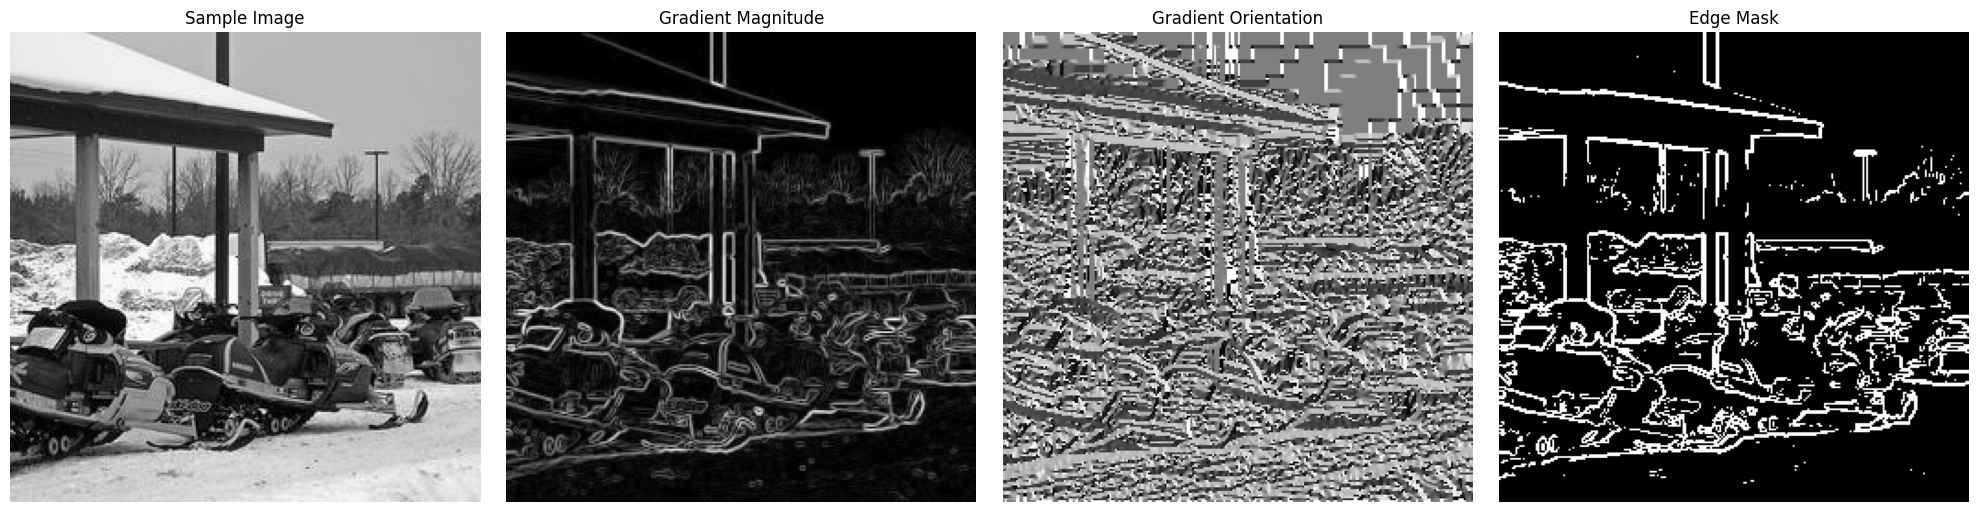

In [19]:
# ============================================
# Cell 4: Preview and Validate Sample Image
# ============================================

import matplotlib.pyplot as plt

# -------------------------------------------------
# Select a sample image from metadata
# -------------------------------------------------
sample_row = df.iloc[0]
sample_path = sample_row["image_path"]

if VERBOSE:
    print("Sample metadata row:")
    for key, value in sample_row.items():
        print(f"{key}: {value}")

    print(f"\nSample image path: {sample_path}")

if not sample_path.exists():
    raise FileNotFoundError(f"Sample image not found: {sample_path}")

# -------------------------------------------------
# Load sample image in grayscale
# -------------------------------------------------
sample_img = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)

if sample_img is None:
    raise ValueError(f"Could not load sample image: {sample_path}")

if VERBOSE:
    print(f"Loaded sample image shape: {sample_img.shape}")
    print(f"Loaded sample image dtype: {sample_img.dtype}")

# -------------------------------------------------
# Verify expected image properties
# -------------------------------------------------
if len(sample_img.shape) != 2:
    raise ValueError("Expected grayscale image with 2 dimensions.")

if sample_img.shape != (256, 256):
    raise ValueError(f"Expected image shape (256, 256), found {sample_img.shape}")

print("Sample image format verified.")

# -------------------------------------------------
# Compute gradient features for sample image
# -------------------------------------------------
sample_features, gx, gy, mag, ori, edge_mask = extract_gradient_features(sample_img)

if VERBOSE:
    print("\nSample gradient features:")
    for key, value in sample_features.items():
        print(f"{key}: {value:.6f}")

# -------------------------------------------------
# Display sample image and derived gradient views
# -------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title("Sample Image")
axes[0].axis("off")

axes[1].imshow(mag, cmap="gray")
axes[1].set_title("Gradient Magnitude")
axes[1].axis("off")

axes[2].imshow(ori, cmap="gray")
axes[2].set_title("Gradient Orientation")
axes[2].axis("off")

axes[3].imshow(edge_mask, cmap="gray")
axes[3].set_title("Edge Mask")
axes[3].axis("off")

plt.tight_layout()
plt.show()



In [16]:
VERBOSE = True

In [20]:
# ============================================
# Cell 5: Extract Gradient Features for Subset
# ============================================

from tqdm.notebook import tqdm

# -------------------------------------------------
# Extract features for all images in selected subset
# -------------------------------------------------
records = []

print(f"Beginning gradient feature extraction for subset: {SUBSET_NAME}")
print(f"Total images to process: {len(df)}\n")

error_count = 0

for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {SUBSET_NAME} images"):
    image_path = row["image_path"]

    try:
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Could not load image: {image_path}")

        features, _, _, _, _, _ = extract_gradient_features(img)

        record = {
            "filename": row["filename"],
            "class_label": row["class_label"],
            "source_dataset": row["source_dataset"],
            "subset": row["subset"],
        }
        record.update(features)
        records.append(record)

    except Exception as e:
        error_count += 1
        if VERBOSE:
            print(f"Skipping {row['filename']} due to error: {e}")

# -------------------------------------------------
# Convert to dataframe
# -------------------------------------------------
gradient_features_df = pd.DataFrame(records)

# -------------------------------------------------
# Verify output structure
# -------------------------------------------------
expected_columns = [
    "filename",
    "class_label",
    "source_dataset",
    "subset",
    "Mean Gradient",
    "Std Gradient",
    "Max Gradient",
    "Gradient Entropy",
    "Edge Density",
    "Orientation Mean",
    "Orientation Std",
    "Orientation Entropy",
]

missing_columns = [col for col in expected_columns if col not in gradient_features_df.columns]
if missing_columns:
    raise ValueError(f"Missing expected output columns: {missing_columns}")

gradient_features_df = gradient_features_df[expected_columns]

# -------------------------------------------------
# Summary
# -------------------------------------------------
print("\nGradient feature extraction complete.")
print(f"Output shape: {gradient_features_df.shape}")
print(f"Processed images: {len(gradient_features_df)}")
print(f"Expected images:  {len(df)}")

if error_count > 0:
    print(f"Skipped images:   {error_count}")

if len(gradient_features_df) != len(df):
    print("\nWARNING: Some images were skipped during processing.")

if VERBOSE:
    print("\nSample output rows:")
    display(gradient_features_df.head())



Beginning gradient feature extraction for subset: train
Total images to process: 14400



Processing train images:   0%|          | 0/14400 [00:00<?, ?it/s]


Gradient feature extraction complete.
Output shape: (14400, 12)
Processed images: 14400
Expected images:  14400

Sample output rows:


,filename,class_label,source_dataset,subset,Mean Gradient,Std Gradient,Max Gradient,Gradient Entropy,Edge Density,Orientation Mean,Orientation Std,Orientation Entropy
0,rl_imgn_002320.png,rl,ImageNet_1K_256,train,113.284256,148.626465,988.380493,4.200053,0.133926,0.009213,1.708909,4.952383
1,rl_coco_001397.png,rl,MS_COCO_2017,train,58.244781,91.992287,943.153198,3.224193,0.104218,0.003133,1.812218,5.067689
2,rl_imgn_001958.png,rl,ImageNet_1K_256,train,99.089622,129.458405,955.745789,4.071966,0.119492,-0.031641,1.761121,5.136969
3,rl_coco_000800.png,rl,MS_COCO_2017,train,76.498199,114.998993,924.299744,3.541116,0.123779,0.210707,1.640483,5.021997
4,ai_mj_002892.png,ai,Midjourney,train,67.460518,74.748627,801.519836,3.823527,0.113922,-0.004285,1.853334,5.145963


In [22]:
# ============================================
# Cell 6: Save Output
# ============================================

# -------------------------------------------------
# Ensure output directory exists
# -------------------------------------------------
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Save gradient feature dataframe
# -------------------------------------------------
gradient_features_df.to_csv(OUTPUT_FILE, index=False)

if VERBOSE:
    print(f"Saved gradient features to: {OUTPUT_FILE}")
else:
    print("Gradient features saved.")

# -------------------------------------------------
# Verify output file exists
# -------------------------------------------------
if not OUTPUT_FILE.exists():
    raise FileNotFoundError(f"Output file was not created: {OUTPUT_FILE}")

# -------------------------------------------------
# Verify saved row count
# -------------------------------------------------
saved_df = pd.read_csv(OUTPUT_FILE)

if len(saved_df) != len(gradient_features_df):
    raise ValueError(
        f"Saved row count mismatch. Expected {len(gradient_features_df)}, found {len(saved_df)}"
    )

print(f"Verified saved file row count: {len(saved_df)}")



Saved gradient features to: /content/dip-ai-image-detection/metadata/features/train_gradient_features.csv
Verified saved file row count: 14400


In [23]:
# ============================================
# Cell 7: Final Summary
# ============================================

from IPython.display import display, HTML

print("Gradient feature extraction completed successfully.\n")

print(f"Subset processed : {SUBSET_NAME}")
print(f"Input rows       : {len(df)}")
print(f"Output rows      : {len(gradient_features_df)}")
print(f"Output columns   : {len(gradient_features_df.columns)}")
print(f"Saved file       : {OUTPUT_FILE}")

print("\nFeature columns:")
for col in gradient_features_df.columns[4:]:
    print(f"  - {col}")

if SUBSET_NAME == TRAIN_SUBSET:
    message = """
    <b>Next Step:</b><br>
    Set <code>SUBSET_NAME = TEST_SUBSET</code> in Cell #1 and rerun this notebook to generate <b>test</b> gradient features.
    """
    border_color = "#ff9800"
    bg_color = "#fff3e0"
else:
    message = f"""
    <b>Current Run Complete:</b><br>
    This run generated <b>{OUTPUT_FILE.name}</b> for the <b>test</b> subset.<br>
    Notebook completed.
    """
    border_color = "#4CAF50"
    bg_color = "#E8F5E9"

display(HTML(f"""
<div style="
    padding: 15px;
    border: 2px solid {border_color};
    background-color: {bg_color};
    border-radius: 8px;
    font-size: 16px;
">
{message}
</div>
"""))



Gradient feature extraction completed successfully.

Subset processed : train
Input rows       : 14400
Output rows      : 14400
Output columns   : 12
Saved file       : /content/dip-ai-image-detection/metadata/features/train_gradient_features.csv

Feature columns:
  - Mean Gradient
  - Std Gradient
  - Max Gradient
  - Gradient Entropy
  - Edge Density
  - Orientation Mean
  - Orientation Std
  - Orientation Entropy
